In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV = "lob_btcusdt_20lvl_100ms.csv"
LEVELS = 20

df = pd.read_csv(CSV, parse_dates=["timestamp"])
bid_px = df[[f"bid_px_{i}" for i in range(1, LEVELS + 1)]].to_numpy()
bid_sz = df[[f"bid_sz_{i}" for i in range(1, LEVELS + 1)]].to_numpy()
ask_px = df[[f"ask_px_{i}" for i in range(1, LEVELS + 1)]].to_numpy()
ask_sz = df[[f"ask_sz_{i}" for i in range(1, LEVELS + 1)]].to_numpy()

mid = (bid_px[:, 0] + ask_px[:, 0]) / 2
spread = ask_px[:, 0] - bid_px[:, 0]
t = (df["recv_ts_ms"] - df["recv_ts_ms"].iloc[0]) / 1000  # seconds from start
print(df.shape, "| span %.0f s" % t.iloc[-1])

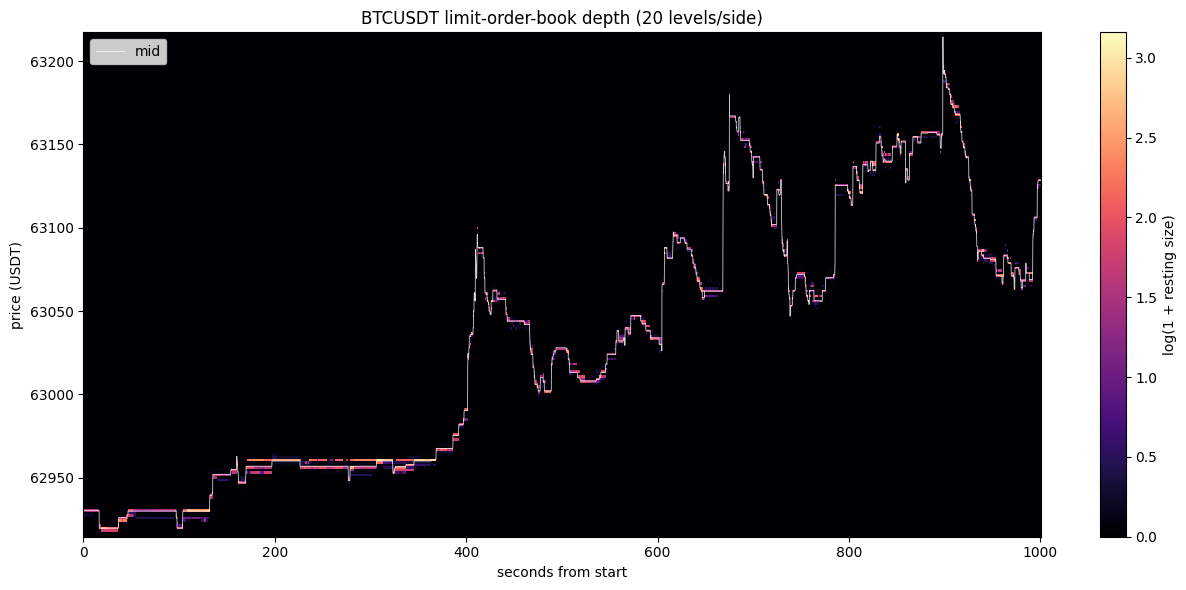

In [6]:
# Order-book depth heatmap: resting size binned onto a price grid over time.
# Dark band = the spread; white line = mid-price.
NBINS = 200
edges = np.linspace(bid_px.min(), ask_px.max(), NBINS + 1)
centers = (edges[:-1] + edges[1:]) / 2
T = len(df)
grid = np.zeros((NBINS, T))
for k in range(T):
    bi = np.clip(np.digitize(bid_px[k], edges) - 1, 0, NBINS - 1)
    ai = np.clip(np.digitize(ask_px[k], edges) - 1, 0, NBINS - 1)
    np.add.at(grid[:, k], bi, bid_sz[k])
    np.add.at(grid[:, k], ai, ask_sz[k])

fig, ax = plt.subplots(figsize=(13, 6))
mesh = ax.pcolormesh(t, centers, np.log1p(grid), cmap="magma", shading="auto")
ax.plot(t, mid, color="white", lw=0.6, alpha=0.8, label="mid")
ax.set_xlabel("seconds from start"); ax.set_ylabel("price (USDT)")
ax.set_title("BTCUSDT limit-order-book depth (20 levels/side)")
ax.legend(loc="upper left")
fig.colorbar(mesh, ax=ax, label="log(1 + resting size)")
plt.tight_layout(); plt.show()

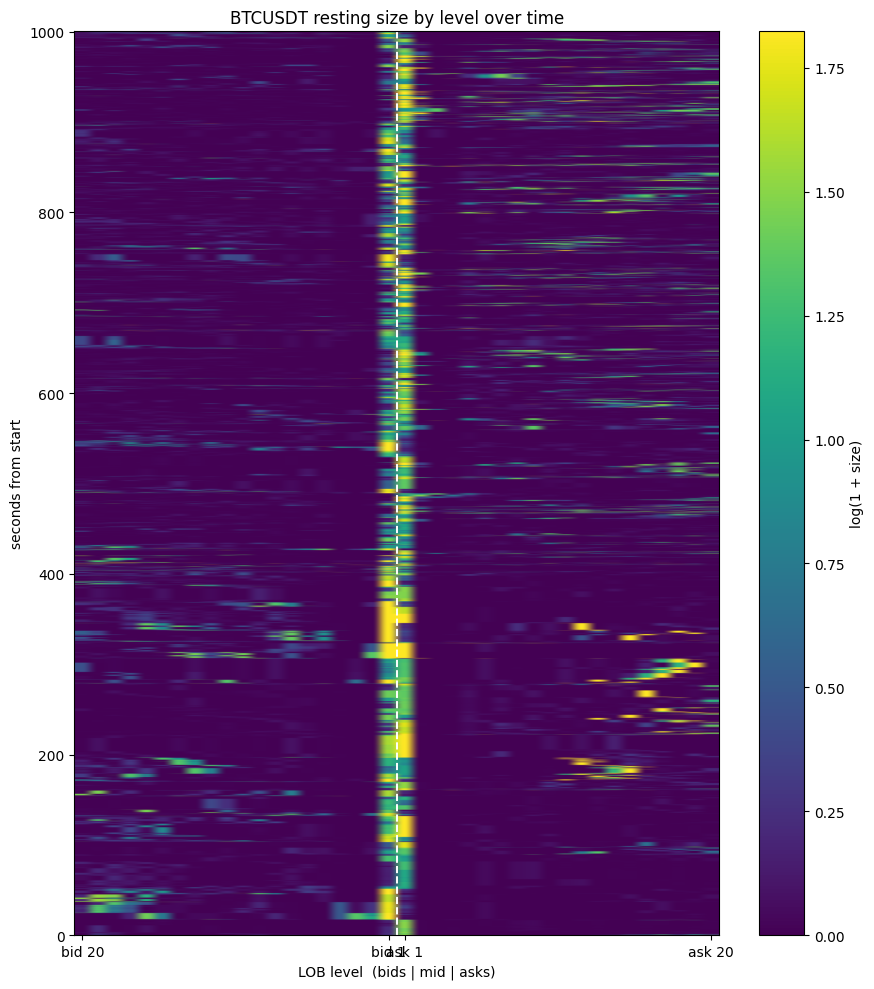

In [8]:
# Level grid: y = time, x = LOB level (price ignored, mid pinned to the centre),
# cell hue = resting size at that level.
# Columns left->right: deepest bid (20) .. best bid (1) | best ask (1) .. deepest ask (20)
size_grid = np.hstack([bid_sz[:, ::-1], ask_sz])          # (T, 2*LEVELS); centre = mid
vmax = np.percentile(np.log1p(size_grid), 99)             # robust to giant orders

fig, ax = plt.subplots(figsize=(9, 10))
im = ax.imshow(np.log1p(size_grid), aspect="auto", origin="lower", cmap="viridis",
               vmin=0, vmax=vmax,
               extent=[0, 2 * LEVELS, t.iloc[0], t.iloc[-1]])
ax.axvline(LEVELS, color="white", lw=1.4, ls="--")        # mid: always centred
ax.set_xticks([0.5, LEVELS - 0.5, LEVELS + 0.5, 2 * LEVELS - 0.5])
ax.set_xticklabels(["bid 20", "bid 1", "ask 1", "ask 20"])
ax.set_xlabel("LOB level  (bids | mid | asks)")
ax.set_ylabel("seconds from start")
ax.set_title("BTCUSDT resting size by level over time")
fig.colorbar(im, ax=ax, label="log(1 + size)")
plt.tight_layout(); plt.show()